# PCA on Correlation Matrices (Train Fit, Test Evaluation)
Fit PCA on flattened train correlation matrices and reconstruct the test matrices using the learned components.
Compute reconstruction errors (MSE, MAE, Frobenius) on the test set, while explained variance is reported from the train fit.

In [71]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder under `data/processed/dataset/`.
The folder must contain `train.pt`, `val.pt`, and `test.pt` with correlation matrices already split.

In [72]:
# Dataset path configuration
FILE_NAME = 'data_00_20'
WINDOW_SIZE = 252
STRIDE = 5
DATASET_DIR = Path('../data/processed') / FILE_NAME / 'dataset' / f'{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}'

TRAIN_FILE = DATASET_DIR / 'train.pt'
VAL_FILE = DATASET_DIR / 'val.pt'
TEST_FILE = DATASET_DIR / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(f'File not found: {split_path.resolve()}')

print(f'Dataset folder: {DATASET_DIR.name}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Dataset folder: data_00_20_w252_s5
Train: train.pt | Val: val.pt | Test: test.pt


In [73]:
def load_dataset_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k not in ('corr_tensor', 'cholesky_L')}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_dataset_payload(TRAIN_FILE)
val_corr, val_meta = load_dataset_payload(VAL_FILE)
test_corr, test_meta = load_dataset_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')


print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (614, 100, 100)
val_corr shape:   (131, 100, 100)
test_corr shape:  (133, 100, 100)


## Step 2: Prepare Train/Val/Test Matrices
Each correlation matrix is loaded as N x N.
If PCA_INPUT='cholesky_lower', PCA uses the flattened lower-triangular Cholesky factors (including diagonal).
If PCA_INPUT='corr', PCA uses the flattened lower-triangular correlations (excluding diagonal).
The validation split is loaded for completeness but not used later.

In [74]:
train_np = train_corr.numpy()
val_np = val_corr.numpy()
test_np = test_corr.numpy()

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]

print(f'Train matrices: {n_train}')
print(f'Val matrices:   {n_val}')
print(f'Test matrices:  {n_test}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')


feature_dim = n_assets * (n_assets - 1) // 2

print(f'Flattened feature dimension: {feature_dim}')

Train matrices: 614
Val matrices:   131
Test matrices:  133
Assets per matrix (N): 100
Each input matrix shape: (100, 100)
Flattened feature dimension: 4950


## Step 3: Fit PCA on Train, Reconstruct Test
For every matrix:
- If PCA_INPUT='cholesky_lower', flatten the lower-triangular Cholesky factor (including diagonal)
- If PCA_INPUT='corr', flatten the lower-triangular correlations (excluding diagonal)
- Fit PCA on the train split only
- Apply PCA to the test split and inverse transform to reconstruct
If using Cholesky, reconstructed correlation matrices are obtained via $L L^T$ and re-normalized to unit diagonal;
if using correlations, the lower triangle is mirrored and the diagonal is set to 1.
Errors are computed on the test split; explained variance is from the train fit.

In [75]:
def apply_pca(
    train_corr,
    eval_corr,
    n_components,
 ):
    
    if train_corr.ndim != 3 or train_corr.shape[1] != train_corr.shape[2]:
        raise ValueError(f'Expected train shape (n_samples, N, N), got {train_corr.shape}')
    if eval_corr.ndim != 3 or eval_corr.shape[1] != eval_corr.shape[2]:
        raise ValueError(f'Expected eval shape (n_samples, N, N), got {eval_corr.shape}')

    n_train, n_assets, _ = train_corr.shape
    n_eval, n_assets_eval, _ = eval_corr.shape
    if n_assets_eval != n_assets:
        raise ValueError(f'Train/eval asset dims mismatch: {train_corr.shape} vs {eval_corr.shape}')

    
    tril_idx = np.tril_indices(n_assets, k=-1)
    train_flat = train_corr[:, tril_idx[0], tril_idx[1]]
    eval_flat = eval_corr[:, tril_idx[0], tril_idx[1]]

    n_features = train_flat.shape[1]
    if not (1 <= n_components <= min(n_train, n_features)):
        raise ValueError(f'n_components must be in [1, {min(n_train, n_features)}]')

    # Fit PCA on train, then reconstruct eval
    pca = PCA(n_components=n_components)
    pca.fit(train_flat)
    eval_recon = pca.inverse_transform(pca.transform(eval_flat))

    
    recon_corr = np.zeros((n_eval, n_assets, n_assets), dtype=eval_recon.dtype)
    recon_corr[:, tril_idx[0], tril_idx[1]] = eval_recon
    recon_corr = recon_corr + np.transpose(recon_corr, (0, 2, 1))
    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return {
        'recon_corr': recon_corr,
        'explained_variance': pca.explained_variance_ratio_,
        'pca': pca,
    }

In [76]:
N_COMPONENTS = 3
max_components = min(n_train, feature_dim)

pca_out = apply_pca(
    train_np,
    test_np,
    n_components=N_COMPONENTS,
)
recon_corr = pca_out['recon_corr']
mean_explained_ratio = pca_out['explained_variance']
pca = pca_out['pca']

var_percent = mean_explained_ratio.sum() * 100
print('--- PCA Reconstruction (train fit, test eval) ---')
print(f'Train tensor shape:         {train_np.shape}')
print(f'Test tensor shape:          {test_np.shape}')
print(f'Reconstructed test shape:   {recon_corr.shape}')
print(f'Components kept (K):        {N_COMPONENTS}')
print(f'Cumulative explained variance (train): {var_percent:.2f}%\n')
for idx, var in enumerate(mean_explained_ratio):
    print(f'Variance PC{idx+1} (train): {(var * 100):.2f}%')

--- PCA Reconstruction (train fit, test eval) ---
Train tensor shape:         (614, 100, 100)
Test tensor shape:          (133, 100, 100)
Reconstructed test shape:   (133, 100, 100)
Components kept (K):        3
Cumulative explained variance (train): 81.82%

Variance PC1 (train): 72.50%
Variance PC2 (train): 5.02%
Variance PC3 (train): 4.30%


## Step 4: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.2769 0.0446 0.1545 0.341 ]
 [0.2769 1.     0.1668 0.3001 0.3637]
 [0.0446 0.1668 1.     0.2089 0.2174]
 [0.1545 0.3001 0.2089 1.     0.2227]
 [0.341  0.3637 0.2174 0.2227 1.    ]]
Reconstructed Matrix:
[[1.     0.2113 0.1777 0.1931 0.2179]
 [0.2113 1.     0.2266 0.2356 0.2853]
 [0.1777 0.2266 1.     0.2431 0.2132]
 [0.1931 0.2356 0.2431 1.     0.2454]
 [0.2179 0.2853 0.2132 0.2454 1.    ]]
Error Matrix:
[[ 0.     -0.0656  0.1331  0.0386 -0.1231]
 [-0.0656  0.      0.0599 -0.0645 -0.0784]
 [ 0.1331  0.0599  0.      0.0343 -0.0042]
 [ 0.0386 -0.0645  0.0343  0.      0.0226]
 [-0.1231 -0.0784 -0.0042  0.0226  0.    ]]
Sample index: 0
MSE: 0.011167 | MAE: 0.082711 | Frobenius: 10.567320
Error range - Min: -0.396022 | Max: 0.424399


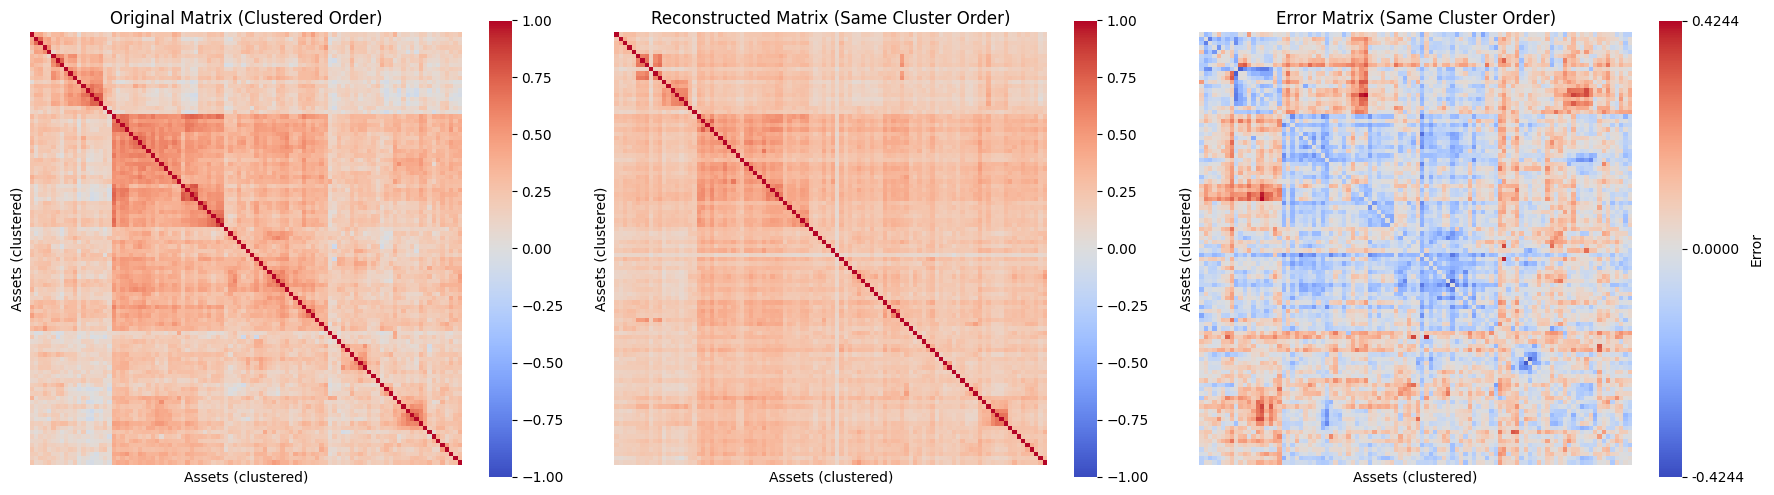

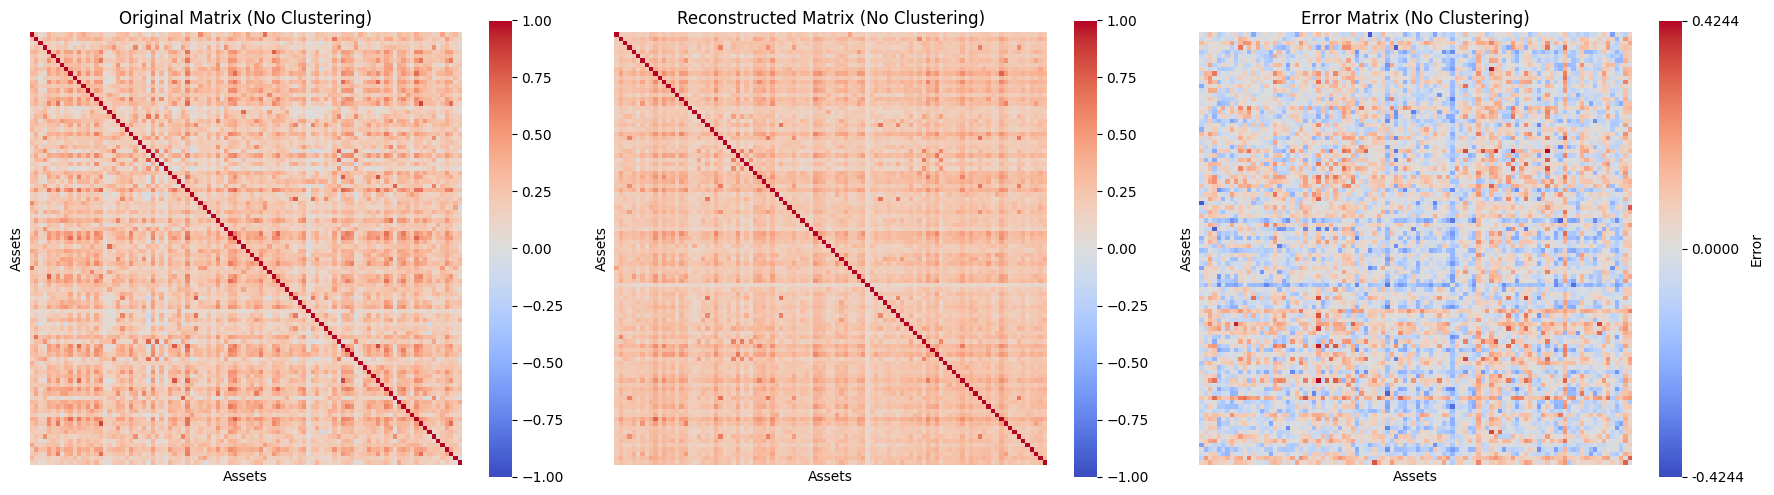

In [77]:
SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_mat = test_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

# Use the same colormap for all matrices.
shared_cmap = 'coolwarm'

# Error scale must be symmetric around zero: [-max|err|, +max|err|]
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

# Clustered heatmaps in a single side-by-side figure (without dendrograms).
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(err_mat, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max, cmap=shared_cmap, center=0, square=True, cbar_kws={'label': 'Error'})
axes[2].set_title('Error Matrix (No Clustering)')
# Set colorbar ticks for standard heatmap
cbar = hm.collections[0].colorbar
cbar.set_ticks([-err_abs_max, 0, err_abs_max])
cbar.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 5: Calculate Reconstruction Errors (Train/Test)
Measure reconstruction quality on the train and test splits using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [78]:
def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    if original.shape != reconstructed.shape:
        raise ValueError(f'Input shapes mismatch: {original.shape} vs {reconstructed.shape}')

    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })
    
    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats


# Test set errors (matrices)
orig_corr = test_np
errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)
print('--- Matrix Reconstruction Errors (Test Set) ---')
display(errors_stats)



--- Matrix Reconstruction Errors (Test Set) ---


,mean,std,min,median,max
MSE,0.015654,0.003802,0.011167,0.013837,0.022951
MAE,0.097328,0.011514,0.082711,0.091988,0.118322
Frobenius,12.425263,1.471581,10.567320,11.762890,15.149745


## Step 7: Error Analysis Across Components
Sweep over different numbers of K components, fitting PCA on the train split and evaluating reconstruction errors on the train and test sets.

In [79]:
# Error evaluation varying number of components (PCA fit on train, reconstruction on train/test)
import json

candidate_components = [3, 10, 20, 50, 70, 100, 150, 614]
max_components = min(n_train, feature_dim)
candidate_components = [c for c in candidate_components if c <= max_components]
print(f'Evaluating reconstruction errors for components: {candidate_components}')


def reconstruction_errors_flat(original_flat: np.ndarray, reconstructed_flat: np.ndarray):
    if original_flat.shape != reconstructed_flat.shape:
        raise ValueError(f'Input shapes mismatch: {original_flat.shape} vs {reconstructed_flat.shape}')

    diff = original_flat - reconstructed_flat
    mse_per_vec = np.mean(diff ** 2, axis=1)
    mae_per_vec = np.mean(np.abs(diff), axis=1)
    l2_per_vec = np.linalg.norm(diff, axis=1)

    summary = pd.DataFrame({
        'MSE': mse_per_vec,
        'MAE': mae_per_vec,
        'L2': l2_per_vec,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats


base_payload = torch.load(TEST_FILE, map_location='cpu')
if isinstance(base_payload, dict):
    base_payload_template = base_payload
else:
    base_payload_template = {'corr_tensor': base_payload}

tickers = None
if isinstance(base_payload, dict):
    if 'tickers' in base_payload:
        tickers = base_payload.get('tickers')
    else:
        meta = base_payload.get('meta') or base_payload.get('metadata')
        if isinstance(meta, dict) and 'tickers' in meta:
            tickers = meta.get('tickers')

tril_idx = np.tril_indices(n_assets, k=-1)
orig_flat = test_np[:, tril_idx[0], tril_idx[1]]
train_flat = train_np[:, tril_idx[0], tril_idx[1]]

rows = []
sweep_payload = []
stat_cols = ["mean", "std", "min", "median", "max"]

for n_comp in candidate_components:
    # Prepare output directory and base payload (same save format as notebook 09)
    recon_dir = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/PCA/PCA_{n_comp}dim/analysis_outputs')
    recon_dir.mkdir(parents=True, exist_ok=True)
    pca_out = apply_pca(
        train_np,
        test_np,
        n_components=n_comp,
    )
    recon = pca_out['recon_corr']
    pca = pca_out['pca']

    # Matrix errors (test)
    _, matrix_stats = reconstruction_errors(test_np, recon)

    # Matrix errors (train)
    train_recon_flat = pca.inverse_transform(pca.transform(train_flat))
    train_recon_corr = np.zeros_like(train_np)
    train_recon_corr[:, tril_idx[0], tril_idx[1]] = train_recon_flat
    train_recon_corr = train_recon_corr + np.transpose(train_recon_corr, (0, 2, 1))
    diag_idx = np.arange(n_assets)
    train_recon_corr[:, diag_idx, diag_idx] = 1.0
    _, train_matrix_stats = reconstruction_errors(train_np, train_recon_corr)

    # Lower-triangular errors (test)
    recon_flat = recon[:, tril_idx[0], tril_idx[1]]
    _, vector_stats = reconstruction_errors_flat(orig_flat, recon_flat)

    # Lower-triangular errors (train)
    _, train_vector_stats = reconstruction_errors_flat(train_flat, train_recon_flat)

    explained_ratio = pca_out['explained_variance']
    cum_explained_ratio = float(explained_ratio.sum())

    # Save reconstructed test matrices for this K (same payload structure as notebook 09)
    extended_payload = dict(base_payload_template)
    extended_payload['corr_tensor_reconstructed'] = torch.from_numpy(recon).float()
    if tickers is not None:
        extended_payload['tickers'] = tickers
    output_path = recon_dir / f'test_reconstructed_PCA_{n_comp}dim.pt'
    torch.save(extended_payload, output_path)
    print(f'Saved reconstructed matrices for K={n_comp}: {output_path.resolve()}')

    err_stats = {}
    for metric_name in ["MSE", "MAE", "Frobenius"]:
        if metric_name in matrix_stats.index:
            metric_stats = matrix_stats.loc[metric_name, stat_cols]
            err_stats[metric_name] = {k: float(metric_stats[k]) for k in stat_cols}

    train_err_stats = {}
    for metric_name in ["MSE", "MAE", "Frobenius"]:
        if metric_name in train_matrix_stats.index:
            metric_stats = train_matrix_stats.loc[metric_name, stat_cols]
            train_err_stats[metric_name] = {k: float(metric_stats[k]) for k in stat_cols}

    vector_err_stats = {}
    for metric_name in ["MSE", "MAE", "L2"]:
        if metric_name in vector_stats.index:
            metric_stats = vector_stats.loc[metric_name, stat_cols]
            vector_err_stats[metric_name] = {k: float(metric_stats[k]) for k in stat_cols}

    train_vector_err_stats = {}
    for metric_name in ["MSE", "MAE", "L2"]:
        if metric_name in train_vector_stats.index:
            metric_stats = train_vector_stats.loc[metric_name, stat_cols]
            train_vector_err_stats[metric_name] = {k: float(metric_stats[k]) for k in stat_cols}

    rows.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'Test_matrix_MSE_mean': float(err_stats["MSE"]["mean"]),
        'Test_matrix_MAE_mean': float(err_stats["MAE"]["mean"]),
        'Test_matrix_Frobenius_mean': float(err_stats["Frobenius"]["mean"]),
        'Train_matrix_MSE_mean': float(train_err_stats["MSE"]["mean"]),
        'Train_matrix_MAE_mean': float(train_err_stats["MAE"]["mean"]),
        'Train_matrix_Frobenius_mean': float(train_err_stats["Frobenius"]["mean"]),
        'Test_lower_MSE_mean': float(vector_err_stats["MSE"]["mean"]),
        'Test_lower_MAE_mean': float(vector_err_stats["MAE"]["mean"]),
        'Test_lower_L2_mean': float(vector_err_stats["L2"]["mean"]),
        'Train_lower_MSE_mean': float(train_vector_err_stats["MSE"]["mean"]),
        'Train_lower_MAE_mean': float(train_vector_err_stats["MAE"]["mean"]),
        'Train_lower_L2_mean': float(train_vector_err_stats["L2"]["mean"]),
    })

    sweep_payload.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'reconstruction_errors_on_matrix_test': err_stats,
        'reconstruction_errors_on_matrix_train': train_err_stats,
        'reconstruction_errors_on_lower_test': vector_err_stats,
        'reconstruction_errors_on_lower_train': train_vector_err_stats,
    })

sweep_df = pd.DataFrame(rows)

# Print two summary tables
print('--- Train summary (matrix + lower) ---')
train_cols = [
    'n_components',
    'mean_explained_variance',
    'Train_matrix_MSE_mean',
    'Train_matrix_MAE_mean',
    'Train_matrix_Frobenius_mean',
    'Train_lower_MSE_mean',
    'Train_lower_MAE_mean',
    'Train_lower_L2_mean',
]
display(sweep_df[train_cols])

print('--- Test summary (matrix + lower) ---')
test_cols = [
    'n_components',
    'mean_explained_variance',
    'Test_matrix_MSE_mean',
    'Test_matrix_MAE_mean',
    'Test_matrix_Frobenius_mean',
    'Test_lower_MSE_mean',
    'Test_lower_MAE_mean',
    'Test_lower_L2_mean',
]
display(sweep_df[test_cols])


sweep_path = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/PCA/reconstruction_errors.json')
sweep_path.parent.mkdir(parents=True, exist_ok=True)
with open(sweep_path, 'w') as f:
    json.dump(sweep_payload, f, indent=2)
print(f'Saved sweep_payload to: {sweep_path.resolve()}')


Evaluating reconstruction errors for components: [3, 10, 20, 50, 70, 100, 150, 614]
Saved reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\PCA_3dim\analysis_outputs\test_reconstructed_PCA_3dim.pt
Saved reconstructed matrices for K=10: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\PCA_10dim\analysis_outputs\test_reconstructed_PCA_10dim.pt
Saved reconstructed matrices for K=20: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\PCA_20dim\analysis_outputs\test_reconstructed_PCA_20dim.pt
Saved reconstructed matrices for K=50: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\PCA_50dim\analysis_outputs\test_reconstructed_PCA_50dim.pt
Saved reconstructed matrices for K=70: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\d

,n_components,mean_explained_variance,Train_matrix_MSE_mean,Train_matrix_MAE_mean,Train_matrix_Frobenius_mean,Train_lower_MSE_mean,Train_lower_MAE_mean,Train_lower_L2_mean
0,3,0.818216,4.307317e-03,5.116454e-02,6.498111,4.350825e-03,5.168136e-02,4.594858
1,10,0.937865,1.472267e-03,2.909301e-02,3.736859,1.487138e-03,2.938688e-02,2.642359
2,20,0.979445,4.870380e-04,1.680042e-02,2.176581,4.919576e-04,1.697012e-02,1.539075
3,50,0.993565,1.524693e-04,9.259094e-03,1.203296,1.540094e-04,9.352621e-03,0.850859
4,70,0.995826,9.889156e-05,7.450327e-03,0.970764,9.989046e-05,7.525583e-03,0.686434
5,100,0.997437,6.073057e-05,5.825827e-03,0.761573,6.134401e-05,5.884674e-03,0.538513
6,150,0.998588,3.346442e-05,4.340959e-03,0.568635,3.380244e-05,4.384807e-03,0.402086
7,614,1.000000,6.125914e-14,1.990698e-07,0.000025,6.187791e-14,2.010806e-07,0.000017


--- Test summary (matrix + lower) ---


,n_components,mean_explained_variance,Test_matrix_MSE_mean,Test_matrix_MAE_mean,Test_matrix_Frobenius_mean,Test_lower_MSE_mean,Test_lower_MAE_mean,Test_lower_L2_mean
0,3,0.818216,0.015654,0.097328,12.425264,0.015812,0.098311,8.785989
1,10,0.937865,0.014434,0.093429,11.936692,0.014580,0.094373,8.440516
2,20,0.979445,0.013783,0.091010,11.666341,0.013922,0.091929,8.249348
3,50,0.993565,0.011895,0.084769,10.847632,0.012015,0.085626,7.670433
4,70,0.995826,0.011272,0.082386,10.562021,0.011386,0.083218,7.468477
5,100,0.997437,0.009918,0.077287,9.917226,0.010018,0.078068,7.012537
6,150,0.998588,0.008468,0.071246,9.167078,0.008553,0.071965,6.482101
7,614,1.000000,0.005500,0.057594,7.387055,0.005556,0.058175,5.223436


Saved sweep_payload to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\reconstruction_errors.json


## Step 8: Visualize Results
Generate plots showing:
1. **Cumulative explained variance** from the PCA fit on the train set (top K)
2. **Test matrix errors** (MSE, MAE, Frobenius)
3. **Train matrix errors** (MSE, MAE, Frobenius)
4. **Test lower-triangular errors** (MSE, MAE, L2)


Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\plots\cumulative_explained_variance.png


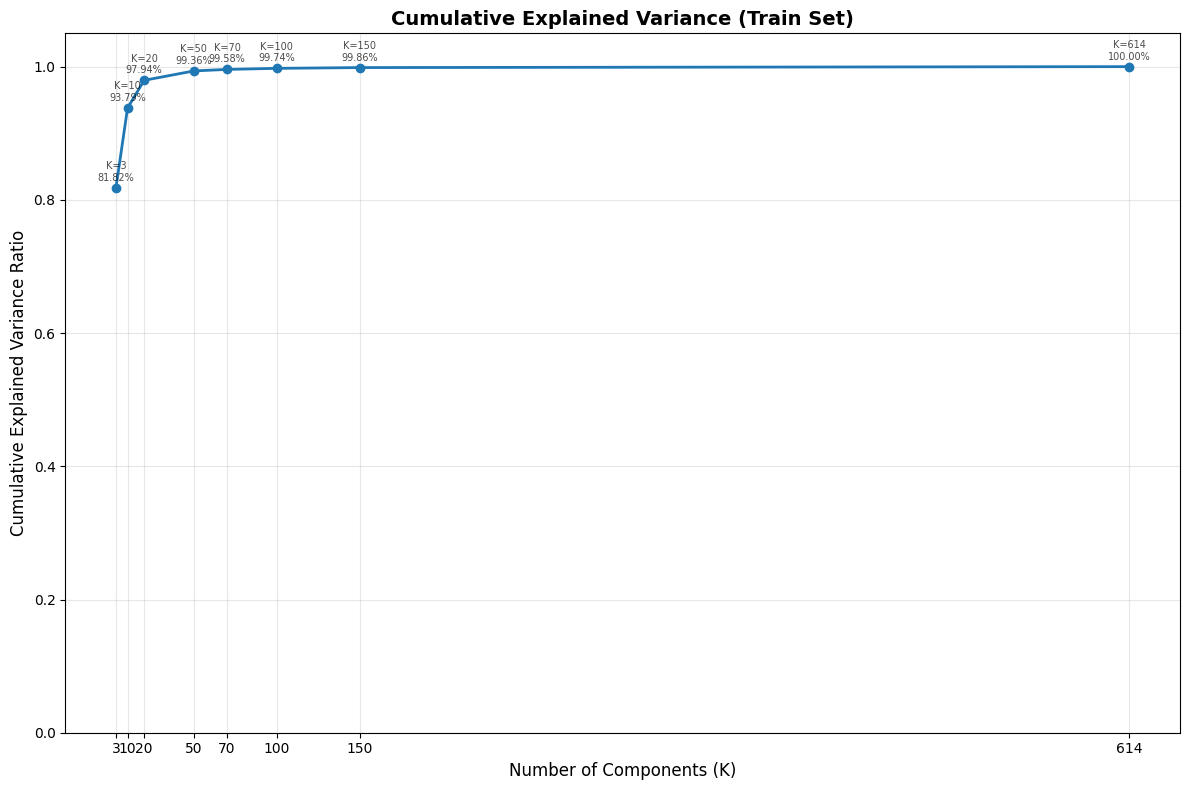

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\plots\reconstruction_errors_train_matrix.png


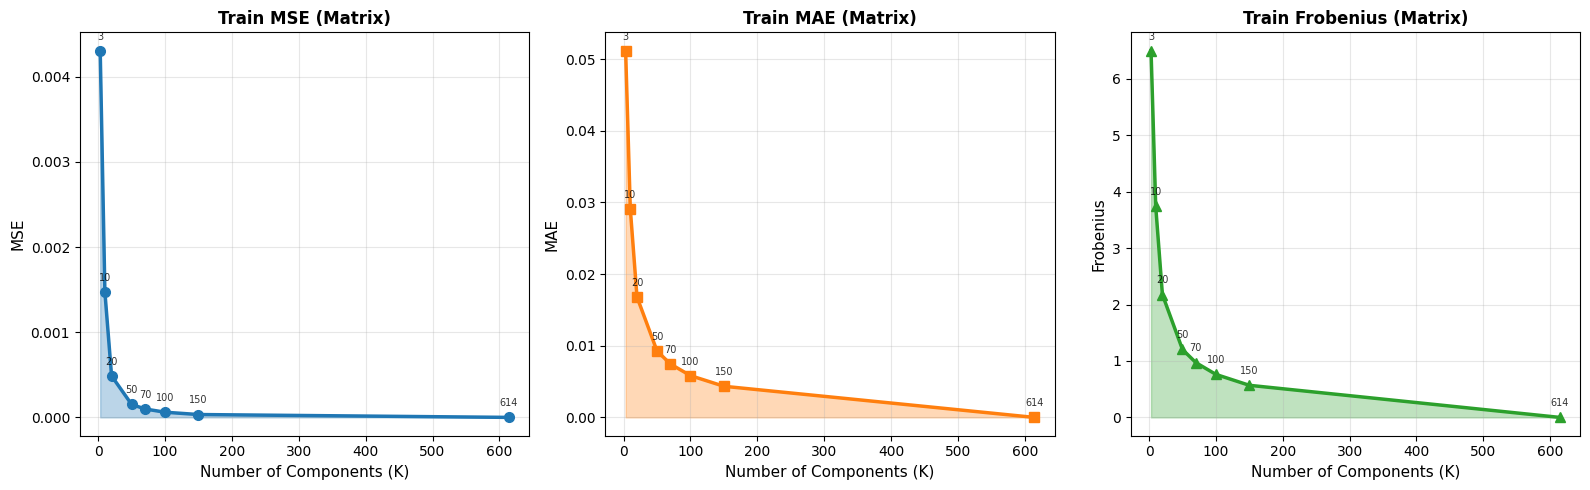

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\plots\reconstruction_errors_train_lower.png


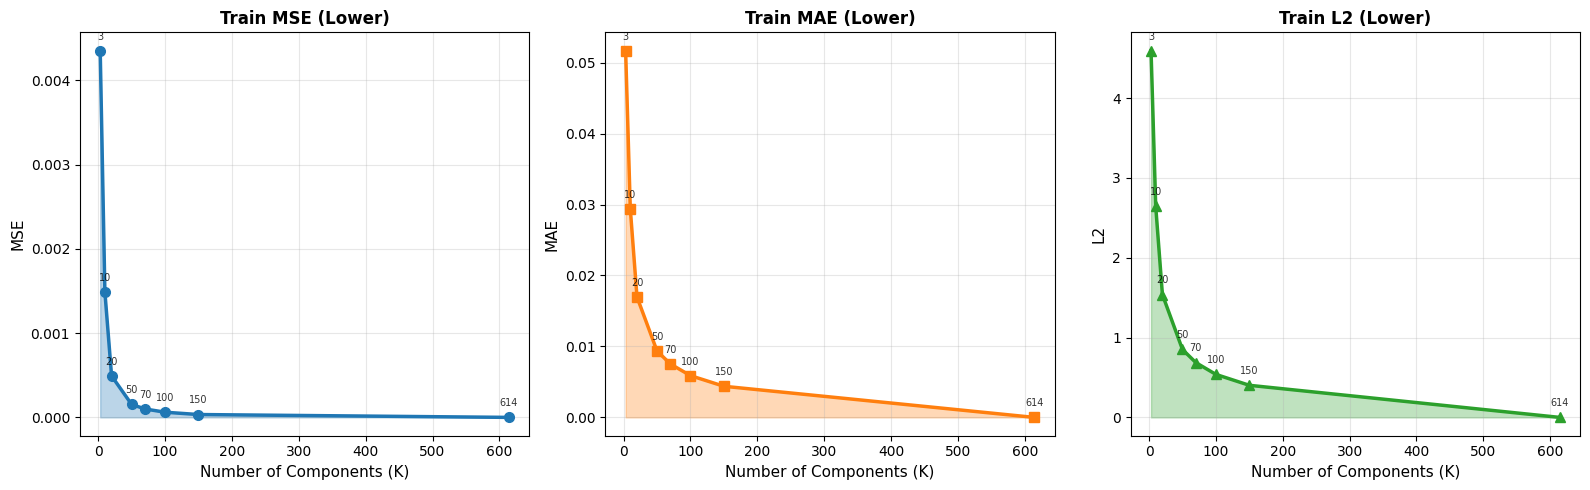

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\plots\reconstruction_errors_test_matrix.png


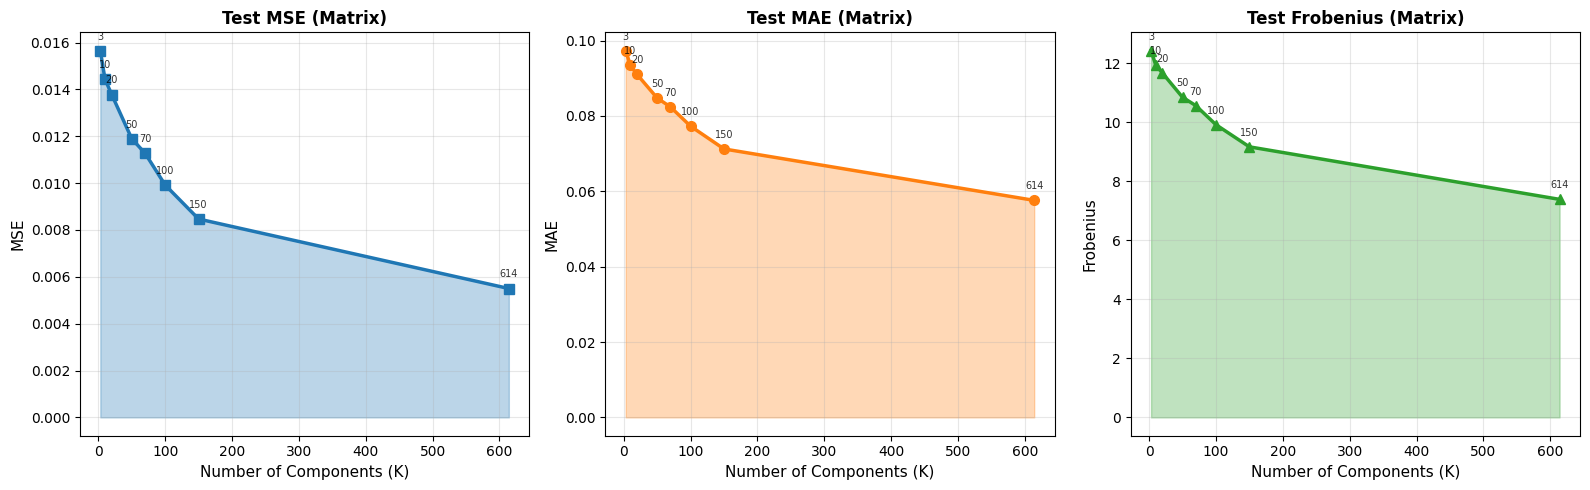

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\PCA\plots\reconstruction_errors_test_lower.png


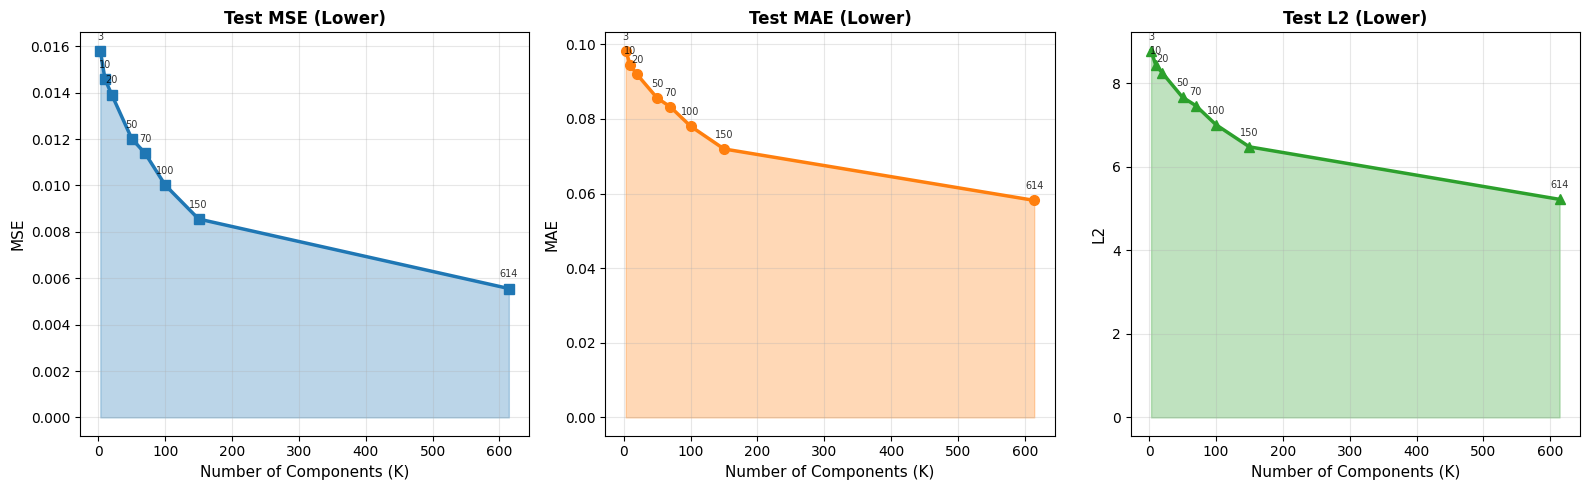

In [80]:
# Plot 1: Cumulative Explained Variance (train fit)
plot_dir = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/PCA/plots')
plot_dir.mkdir(parents=True, exist_ok=True)

fig1, ax1 = plt.subplots(figsize=(12, 8))

k_values = sweep_df['n_components'].to_numpy()
mean_cum_var = sweep_df['mean_explained_variance'].to_numpy()
ax1.plot(k_values, mean_cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for k, val in zip(k_values, mean_cum_var):
    ax1.annotate(f'K={int(k)}\n{val*100:.2f}%',
                 xy=(k, val),
                 xytext=(0, 5),
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title(f'Cumulative Explained Variance (Train Set)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Components (K)', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
plt.tight_layout()

fig1_path = plot_dir / 'cumulative_explained_variance.png'
fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig1_path.resolve()}')

plt.show()

# Plot 2: Train matrix errors (MSE/MAE/Frobenius)
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean']):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[0].set_title(f'Train MSE (Matrix)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Components (K)', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean']):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[1].set_title(f'Train MAE (Matrix)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components (K)', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean']):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[2].set_title(f'Train Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Components (K)', fontsize=11)
axes[2].set_ylabel('Frobenius', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

fig2_path = plot_dir / 'reconstruction_errors_train_matrix.png'
fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig2_path.resolve()}')

plt.show()

# Plot 3: Train Lower-triangular errors (MSE/MAE/Frobenius)
fig3, axes_train = plt.subplots(1, 3, figsize=(16, 5))

axes_train[0].plot(sweep_df['n_components'], sweep_df['Train_lower_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes_train[0].fill_between(sweep_df['n_components'], sweep_df['Train_lower_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_lower_MSE_mean']):
    axes_train[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                           ha='center', fontsize=7, alpha=0.8)
axes_train[0].set_title(f'Train MSE (Lower)', fontsize=12, fontweight='bold')
axes_train[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_train[0].set_ylabel('MSE', fontsize=11)
axes_train[0].grid(True, alpha=0.3)

axes_train[1].plot(sweep_df['n_components'], sweep_df['Train_lower_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_train[1].fill_between(sweep_df['n_components'], sweep_df['Train_lower_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_lower_MAE_mean']):
    axes_train[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                           ha='center', fontsize=7, alpha=0.8)
axes_train[1].set_title(f'Train MAE (Lower)', fontsize=12, fontweight='bold')
axes_train[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_train[1].set_ylabel('MAE', fontsize=11)
axes_train[1].grid(True, alpha=0.3)

axes_train[2].plot(sweep_df['n_components'], sweep_df['Train_lower_L2_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_train[2].fill_between(sweep_df['n_components'], sweep_df['Train_lower_L2_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_lower_L2_mean']):
    axes_train[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                           ha='center', fontsize=7, alpha=0.8)
axes_train[2].set_title(f'Train L2 (Lower)', fontsize=12, fontweight='bold')
axes_train[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_train[2].set_ylabel('L2', fontsize=11)
axes_train[2].grid(True, alpha=0.3)

plt.tight_layout()

fig3_path = plot_dir / 'reconstruction_errors_train_lower.png'
fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig3_path.resolve()}')

plt.show()

# Plot 4: Test matrix errors (MSE/MAE/L2)
fig4, axes_flat = plt.subplots(1, 3, figsize=(16, 5))

axes_flat[0].plot(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean'], marker='s', linewidth=2.5, markersize=7, color='#1f77b4')
axes_flat[0].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean']):
    axes_flat[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                          ha='center', fontsize=7, alpha=0.8)
axes_flat[0].set_title(f'Test MSE (Matrix)', fontsize=12, fontweight='bold')
axes_flat[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_flat[0].set_ylabel('MSE', fontsize=11)
axes_flat[0].grid(True, alpha=0.3)

axes_flat[1].plot(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean'], marker='o', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_flat[1].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean']):
    axes_flat[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                          ha='center', fontsize=7, alpha=0.8)
axes_flat[1].set_title(f'Test MAE (Matrix)', fontsize=12, fontweight='bold')
axes_flat[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_flat[1].set_ylabel('MAE', fontsize=11)
axes_flat[1].grid(True, alpha=0.3)


axes_flat[2].plot(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_flat[2].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean']):
    axes_flat[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                          ha='center', fontsize=7, alpha=0.8)
axes_flat[2].set_title(f'Test Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes_flat[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_flat[2].set_ylabel('Frobenius', fontsize=11)
axes_flat[2].grid(True, alpha=0.3)


plt.tight_layout()

fig4_path = plot_dir / 'reconstruction_errors_test_matrix.png'
fig4.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig4_path.resolve()}')
plt.show()

# Plot 5: Test Lower-triangular errors (MSE/MAE/L2)
fig5, axes_flat = plt.subplots(1, 3, figsize=(16, 5))

axes_flat[0].plot(sweep_df['n_components'], sweep_df['Test_lower_MSE_mean'], marker='s', linewidth=2.5, markersize=7, color='#1f77b4')
axes_flat[0].fill_between(sweep_df['n_components'], sweep_df['Test_lower_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_lower_MSE_mean']):
    axes_flat[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                          ha='center', fontsize=7, alpha=0.8)
axes_flat[0].set_title(f'Test MSE (Lower)', fontsize=12, fontweight='bold')
axes_flat[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_flat[0].set_ylabel('MSE', fontsize=11)
axes_flat[0].grid(True, alpha=0.3)

axes_flat[1].plot(sweep_df['n_components'], sweep_df['Test_lower_MAE_mean'], marker='o', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_flat[1].fill_between(sweep_df['n_components'], sweep_df['Test_lower_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_lower_MAE_mean']):
    axes_flat[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                          ha='center', fontsize=7, alpha=0.8)
axes_flat[1].set_title(f'Test MAE (Lower)', fontsize=12, fontweight='bold')
axes_flat[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_flat[1].set_ylabel('MAE', fontsize=11)
axes_flat[1].grid(True, alpha=0.3)


axes_flat[2].plot(sweep_df['n_components'], sweep_df['Test_lower_L2_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_flat[2].fill_between(sweep_df['n_components'], sweep_df['Test_lower_L2_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_lower_L2_mean']):
    axes_flat[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                          ha='center', fontsize=7, alpha=0.8)
axes_flat[2].set_title(f'Test L2 (Lower)', fontsize=12, fontweight='bold')
axes_flat[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_flat[2].set_ylabel('L2', fontsize=11)
axes_flat[2].grid(True, alpha=0.3)


plt.tight_layout()

fig5_path = plot_dir / 'reconstruction_errors_test_lower.png'
fig5.savefig(fig5_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig5_path.resolve()}')

plt.show()
